In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

In [2]:
result_files = glob.glob("../data/coco/*_results.csv")
if not result_files:
    raise FileNotFoundError("No result CSVs found. Run the model evaluation notebooks first.")

df = pd.concat([pd.read_csv(f) for f in result_files], ignore_index=True)
df = df.sort_values("map50", ascending=False).reset_index(drop=True)
print(df.to_string(index=False))

       model  map50  precision  recall     f1  fps  model_size_mb
   RT-DETR-L 0.6862     0.5139  0.8082 0.6188  2.6           63.4
Faster R-CNN 0.5843     0.6224  0.6786 0.6484  1.8          159.8
    YOLOv11n 0.5000     0.7174  0.5283 0.6052 40.7            5.4
     YOLOv8n 0.4761     0.6951  0.5017 0.5803 39.9            6.2


## mAP@0.5, Precision, Recall, F1

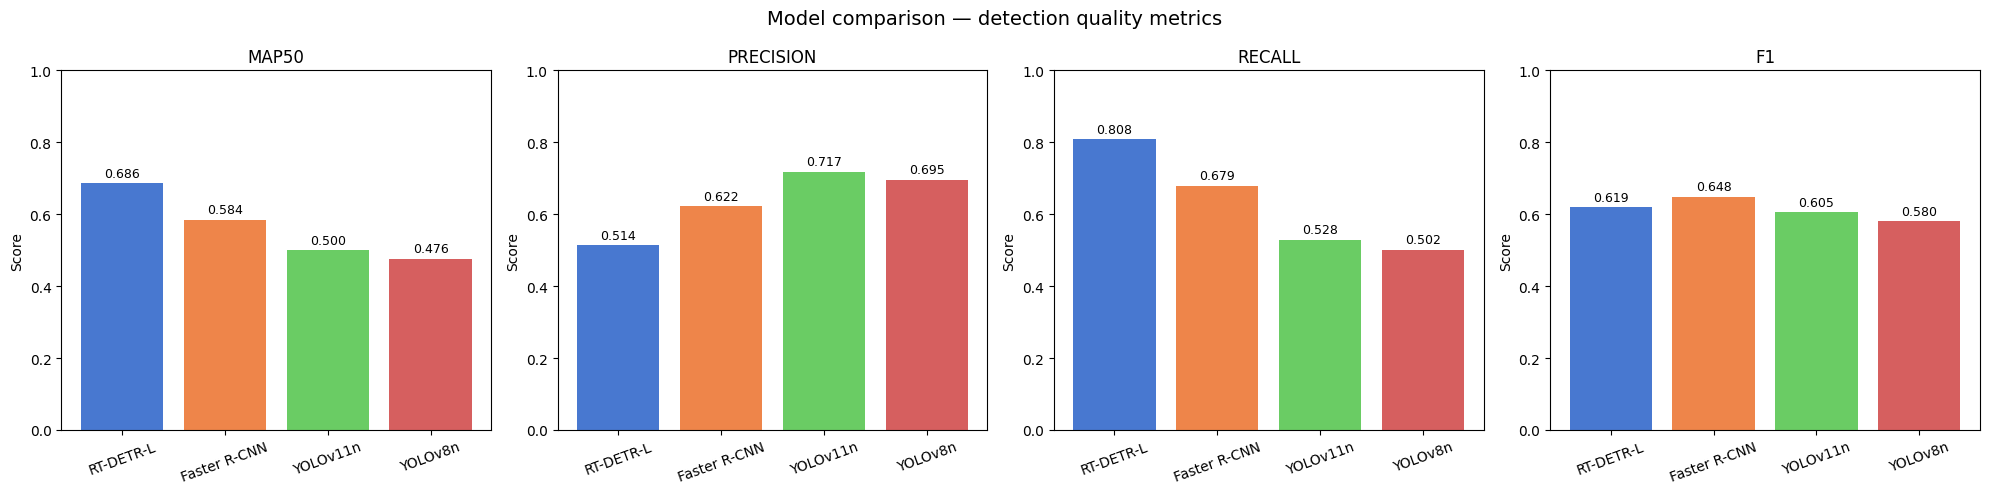

In [3]:
metrics = ["map50", "precision", "recall", "f1"]
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, metric in zip(axes, metrics):
    bars = ax.bar(df["model"], df[metric], color=sns.color_palette("muted", len(df)))
    ax.set_title(metric.upper())
    ax.set_ylim(0, 1)
    ax.set_ylabel("Score")
    ax.tick_params(axis="x", rotation=20)
    for bar, val in zip(bars, df[metric]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f"{val:.3f}", ha="center", va="bottom", fontsize=9)

plt.suptitle("Model comparison — detection quality metrics", fontsize=14)
plt.tight_layout()
plt.savefig("../data/coco/comparison_quality.png", dpi=150, bbox_inches="tight")
plt.show()

## Speed vs Accuracy tradeoff

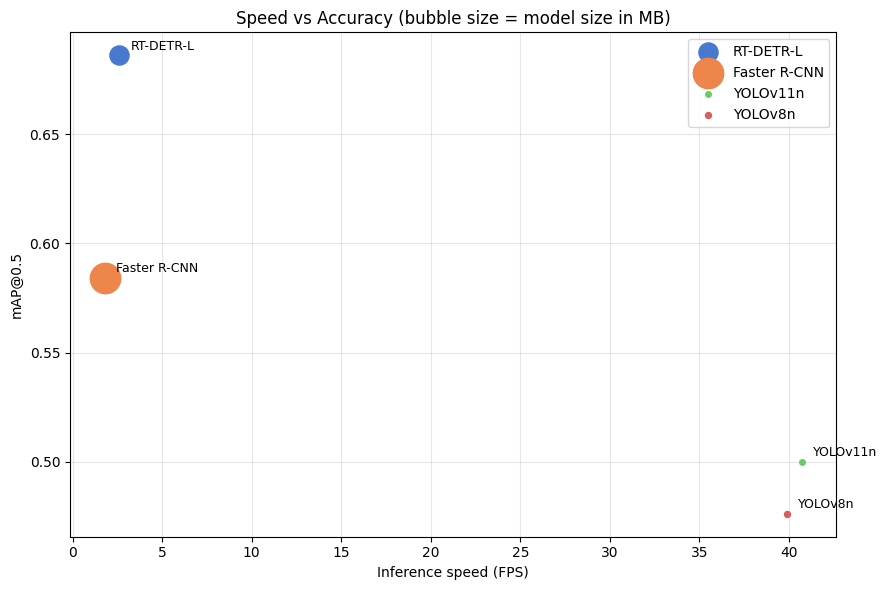

In [4]:
fig, ax = plt.subplots(figsize=(9, 6))
colors = sns.color_palette("muted", len(df))

for i, row in df.iterrows():
    ax.scatter(row["fps"], row["map50"], s=row["model_size_mb"] * 3,
               color=colors[i], label=row["model"], zorder=3)
    ax.annotate(row["model"], (row["fps"], row["map50"]),
                textcoords="offset points", xytext=(8, 4), fontsize=9)

ax.set_xlabel("Inference speed (FPS)")
ax.set_ylabel("mAP@0.5")
ax.set_title("Speed vs Accuracy (bubble size = model size in MB)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../data/coco/comparison_speed_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()

## Model size and speed

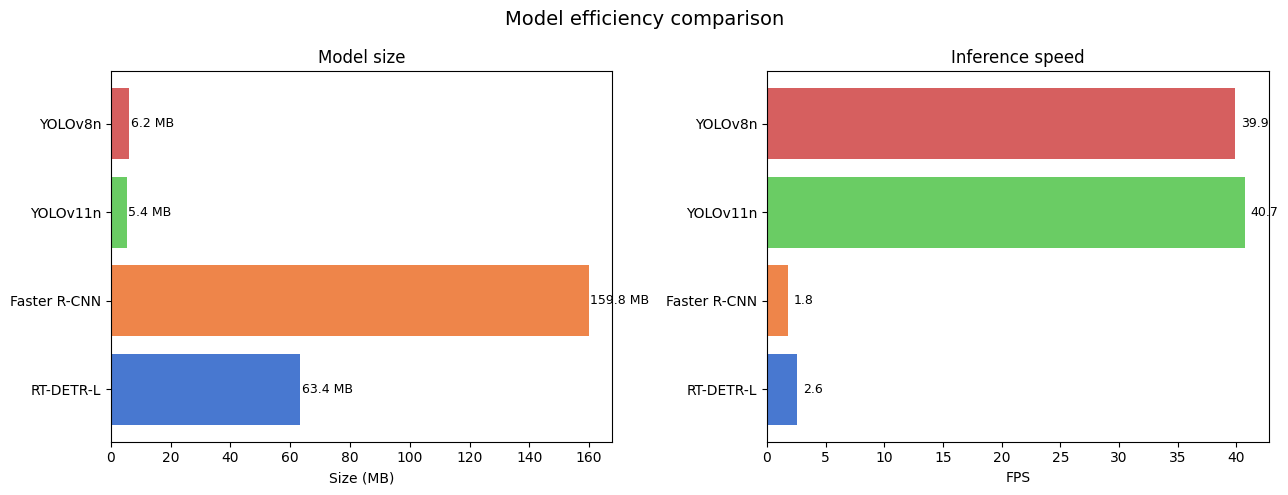

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].barh(df["model"], df["model_size_mb"], color=sns.color_palette("muted", len(df)))
axes[0].set_xlabel("Size (MB)")
axes[0].set_title("Model size")
for i, val in enumerate(df["model_size_mb"]):
    axes[0].text(val + 0.5, i, f"{val:.1f} MB", va="center", fontsize=9)

axes[1].barh(df["model"], df["fps"], color=sns.color_palette("muted", len(df)))
axes[1].set_xlabel("FPS")
axes[1].set_title("Inference speed")
for i, val in enumerate(df["fps"]):
    axes[1].text(val + 0.5, i, f"{val:.1f}", va="center", fontsize=9)

plt.suptitle("Model efficiency comparison", fontsize=14)
plt.tight_layout()
plt.savefig("../data/coco/comparison_efficiency.png", dpi=150, bbox_inches="tight")
plt.show()

## Heatmap — all metrics

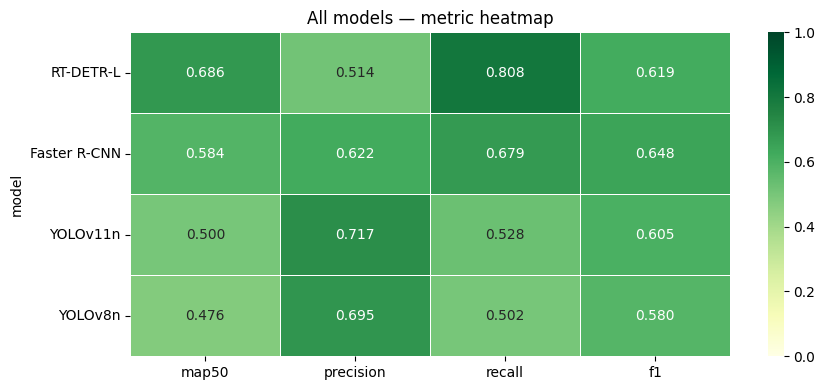

In [6]:
heatmap_cols = ["map50", "precision", "recall", "f1"]
heatmap_df = df.set_index("model")[heatmap_cols]

fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(heatmap_df, annot=True, fmt=".3f", cmap="YlGn", vmin=0, vmax=1,
            linewidths=0.5, ax=ax)
ax.set_title("All models — metric heatmap")
plt.tight_layout()
plt.savefig("../data/coco/comparison_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## Final ranking table

In [7]:
display_df = df[["model", "map50", "precision", "recall", "f1", "fps", "model_size_mb"]].copy()
display_df.columns = ["Model", "mAP@0.5", "Precision", "Recall", "F1", "FPS", "Size (MB)"]
display_df = display_df.reset_index(drop=True)
display_df.index += 1
display_df

,Model,mAP@0.5,Precision,Recall,F1,FPS,Size (MB)
1,RT-DETR-L,0.6862,0.5139,0.8082,0.6188,2.6,63.4
2,Faster R-CNN,0.5843,0.6224,0.6786,0.6484,1.8,159.8
3,YOLOv11n,0.5000,0.7174,0.5283,0.6052,40.7,5.4
4,YOLOv8n,0.4761,0.6951,0.5017,0.5803,39.9,6.2
